# UQLM White-Box Uncertainty Quantification with MedGemma

A compact research notebook comparing ten UQLM-style uncertainty scores for `google/medgemma-4b-it` on medical question-answering prompts.


In [1]:
!pip install -q uqlm bert-score
!pip install -q transformers accelerate sentencepiece sentence-transformers rich optuna \
    langchain-core langchain-model-profiles tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### 1.2 Hugging Face authentication

Add your Hugging Face token to Colab Secrets as `HF_TOKEN`. MedGemma is a gated model, so the token must have access to `google/medgemma-4b-it`. The token is read at runtime and is not stored in the notebook.


In [1]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

assert HF_TOKEN, "Add your Hugging Face token in Colab Secrets as HF_TOKEN."
login(token=HF_TOKEN)
print("Logged in to Hugging Face Hub.")


Logged in to Hugging Face Hub.


### 1.3 Load MedGemma-4B-IT

We load `google/medgemma-4b-it` in `bfloat16` on GPU when available. The same local model is used for original responses, sampled responses, token logprobs, and the P(True) self-evaluation step, so all uncertainty scores are tied to the same model distribution.


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "google/medgemma-4b-it"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} on {DEVICE} ...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
)

model.eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("MedGemma model loaded.")


Loading google/medgemma-4b-it on cuda ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma model loaded.


## 2. Local MedGemma logprob adapter

This adapter bridges **Hugging Face model internals** and the **logprobs schema** consumed by `uqlm` white-box scorers. UQLM expects one generated response to be represented as a list of token dictionaries:

```python
[
  {"token": "The", "logprob": -0.12, "top_logprobs": [{"token": "The", "logprob": -0.12}, ...]},
  ...
]
```

`generate_with_logprobs(...)` runs MedGemma locally with `output_scores=True`, applies `log_softmax` to each generation step, stores the chosen token logprob, and stores the top-k alternatives. This supplies the exact token-level probability inputs needed by UQLM without relying on a hosted API.

The returned `logprobs_result` supports two families of methods: single-token or sequence probability methods use the chosen-token logprobs, while top-k methods use the alternative-token distributions in `top_logprobs`.


In [3]:
import torch.nn.functional as F
import numpy as np

TOP_K_LOGPROBS = 15  # matches uqlm's default top_logprobs width

@torch.no_grad()
def generate_with_logprobs(prompt: str, do_sample: bool = False, temperature: float = 1.0,
                            max_new_tokens: int = 200, top_k_logprobs: int = TOP_K_LOGPROBS,
                            system_prompt: str = None):
    # Generate a single response from MedGemma and return:
    #   - response_text: str
    #   - logprobs_result: List[Dict] in the exact schema uqlm's white-box scorers expect
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})

    # apply_chat_template can return either a raw Tensor or a BatchEncoding,
    # depending on the transformers/tokenizer version -- handle both.
    templated = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt")
    if isinstance(templated, torch.Tensor):
        input_ids = templated.to(model.device)
    else:
        input_ids = templated["input_ids"].to(model.device)

    input_len = input_ids.shape[1]

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        output_scores=True,
        return_dict_in_generate=True,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = 0.95
    else:
        gen_kwargs["temperature"] = None
        gen_kwargs["top_p"] = None

    out = model.generate(input_ids, **gen_kwargs)

    generated_ids = out.sequences[0][input_len:]
    response_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

    logprobs_result = []
    for step_idx, step_logits in enumerate(out.scores):
        if step_idx >= len(generated_ids):
            break
        token_id = generated_ids[step_idx].item()
        if token_id == tokenizer.eos_token_id:
            break

        log_probs = F.log_softmax(step_logits[0].float(), dim=-1)
        chosen_logprob = log_probs[token_id].item()
        chosen_token_str = tokenizer.decode([token_id])

        topk_logprobs, topk_ids = torch.topk(log_probs, k=top_k_logprobs)
        top_logprobs = [
            {"token": tokenizer.decode([tid.item()]), "logprob": lp.item()}
            for lp, tid in zip(topk_logprobs, topk_ids)
        ]
        if not any(abs(tl["logprob"] - chosen_logprob) < 1e-6 for tl in top_logprobs):
            top_logprobs[-1] = {"token": chosen_token_str, "logprob": chosen_logprob}

        logprobs_result.append({"token": chosen_token_str, "logprob": chosen_logprob, "top_logprobs": top_logprobs})

    return response_text.strip(), logprobs_result


def generate_n_samples(prompt: str, n: int = 5, temperature: float = 1.0, max_new_tokens: int = 200):
    # Generate n sampled responses (with logprobs) from the same prompt, for multi-generation scorers.
    texts, logprob_results = [], []
    for _ in range(n):
        text, lp = generate_with_logprobs(prompt, do_sample=True, temperature=temperature, max_new_tokens=max_new_tokens)
        texts.append(text)
        logprob_results.append(lp)
    return texts, logprob_results

print("Adapter functions ready: generate_with_logprobs(), generate_n_samples()")


Adapter functions ready: generate_with_logprobs(), generate_n_samples()


## 3. Prompt set

11 research-level clinical prompts (`p01`-`p11`). **Every technique below runs on this same set**, so score differences reflect the techniques, not the inputs.

`p10` is a deliberate **hallucination trap**: it asks about "XR-7291", a fabricated compound. The model has no reliable grounding for this entity, so a fluent answer may still be fabricated.

`p11` is a factual self-evaluation control prompt. It contains a common false clinical claim about antibiotics treating viral infections, which helps test whether P(True) can recognize an explicitly false premise rather than simply accepting a plausible-sounding answer.


In [4]:
_PREFIX = "Answer concisely in 2-3 sentences covering only the key clinical points.\n\n"

PROMPTS = {
    "p01": _PREFIX + (
        "A 55-year-old man presents with sudden-onset crushing substernal chest pain "
        "radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment "
        "elevation in leads V1-V4 with reciprocal depression in II, III, aVF. "
        "Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the "
        "immediate reperfusion management priority?"
    ),
    "p02": _PREFIX + (
        "A 7-year-old boy presents with a petechial rash, fever of 39.8C, neck "
        "stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low glucose, "
        "and elevated protein; Gram stain reveals Gram-negative diplococci. Which "
        "organism is responsible and what is the first-line empirical antibiotic?"
    ),
    "p03": _PREFIX + (
        "Explain the mechanism by which metformin lowers blood glucose in type 2 "
        "diabetes, specifically its effect on hepatic gluconeogenesis via AMP-activated "
        "protein kinase (AMPK) and inhibition of mitochondrial complex I."
    ),
    "p04": _PREFIX + (
        "A 68-year-old woman with a 40-pack-year smoking history presents with "
        "progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and a "
        "right-sided pleural effusion. CT reveals a 3.2 cm spiculated right upper lobe "
        "mass with ipsilateral mediastinal lymphadenopathy. What is the most likely "
        "diagnosis, and which single investigation best establishes nodal staging to "
        "guide resectability?"
    ),
    "p05": _PREFIX + (
        "A 34-year-old woman has a 2-year history of episodic bloody diarrhoea and "
        "abdominal cramping. Colonoscopy shows continuous mucosal inflammation from the "
        "rectum to the splenic flexure with pseudopolyps; biopsy confirms crypt "
        "abscesses. She has failed mesalazine. What is the next therapeutic step and "
        "the rationale for escalation?"
    ),
    "p06": _PREFIX + (
        "A 72-year-old man with CKD (eGFR 28 mL/min/1.73m2) and heart failure (EF 35%) "
        "is started on an ACE inhibitor. Two weeks later his potassium is 6.1 mEq/L and "
        "creatinine has risen 35%. Explain the pathophysiological mechanism and outline "
        "how you would manage this."
    ),
    "p07": _PREFIX + (
        "Describe the genetic basis, key clinical phenotype, and anaesthetic "
        "implications of malignant hyperthermia. Which triggering agents must be "
        "avoided, and what is the mechanism of action of dantrolene in acute management?"
    ),
    "p08": _PREFIX + (
        "A 28-year-old woman presents with recurrent pregnancy loss, livedo reticularis, "
        "and a DVT. Lupus anticoagulant and anti-cardiolipin IgG are positive on two "
        "occasions 12 weeks apart. Discuss the immunopathological mechanism of "
        "thrombosis in antiphospholipid syndrome and compare the evidence for warfarin "
        "versus DOACs for long-term anticoagulation in this population."
    ),
    "p09": _PREFIX + (
        "Compare the molecular mechanisms of acquired resistance to the third-generation "
        "EGFR tyrosine kinase inhibitor osimertinib in NSCLC, focusing on the C797S "
        "mutation, MET amplification, and small-cell transformation. For each, state the "
        "therapeutic strategy with the strongest current clinical evidence."
    ),
    # p10 is a deliberate hallucination trap: XR-7291 is a fabricated compound.
    "p10": _PREFIX + (
        "Describe the exact molecular mechanism by which the investigational compound "
        "XR-7291 selectively disrupts cardiolipin remodelling in the inner mitochondrial "
        "membrane of drug-resistant glioblastoma stem cells, producing selective "
        "apoptosis without harming normal neural progenitors. Name the key downstream "
        "effectors and the proposed biomarker of response."
    ),
    # p11 is a factual self-evaluation control prompt.
    "p11": _PREFIX + (
        "A patient asks whether amoxicillin is an appropriate treatment for an uncomplicated "
        "viral upper respiratory tract infection because antibiotics kill viruses. Explain "
        "whether this claim is true or false and what the appropriate management should be."
    ),
}

PROMPT_IDS = list(PROMPTS.keys())
PROMPT_LIST = list(PROMPTS.values())
print(f"OK: {len(PROMPTS)} prompts loaded -> {PROMPT_IDS}")


OK: 11 prompts loaded -> ['p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11']


### 3.1 Compact reference answers

The reference dictionary below is used only for interpretation and qualitative comparison. It is **not** passed into UQLM and is never used to compute uncertainty scores.


In [5]:
import pandas as pd

GROUND_TRUTH = {
    "p01": "Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support.",
    "p02": "Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts.",
    "p03": "Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis.",
    "p04": "Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.",
    "p05": "Ulcerative colitis beyond mild disease after mesalazine failure; escalate to corticosteroids for induction and/or biologic/small-molecule therapy depending on severity and maintenance plan.",
    "p06": "ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy.",
    "p07": "Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.",
    "p08": "Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS.",
    "p09": "Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemotherapy regimens.",
    "p10": "No reliable reference answer exists because XR-7291 is fabricated. A grounded answer should explicitly state that the compound, mechanism, and biomarker cannot be verified rather than inventing details.",
    "p11": "False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.",
}

reference_df = pd.DataFrame({
    "prompt_id": PROMPT_IDS,
    "ground_truth": [GROUND_TRUTH[pid] for pid in PROMPT_IDS],
})
reference_df


,prompt_id,ground_truth
0,p01,Anterior STEMI involving V1-V4 with elevated t...
1,p02,Neisseria meningitidis meningitis; give immedi...
2,p03,Metformin reduces hepatic glucose output mainl...
3,p04,Likely non-small-cell lung cancer with mediast...
4,p05,Ulcerative colitis beyond mild disease after m...
5,p06,ACE inhibition reduces angiotensin-II efferent...
6,p07,Usually autosomal-dominant RYR1 or CACNA1S sus...
7,p08,Antiphospholipid syndrome causes antibody-medi...
8,p09,"Osimertinib resistance may involve EGFR C797S,..."
9,p10,No reliable reference answer exists because XR...


## 4. Generation

For every prompt we generate:
- **1 original response** using greedy decoding — this is the response scored by single-generation techniques.
- **N = 5 sampled responses** — used by Monte Carlo probability, CoCoA, Semantic Negentropy, and Semantic Density.



In [6]:
N_SAMPLES = 5
SAMPLE_TEMPERATURE = 1.0
MAX_NEW_TOKENS = 200

original_responses = {}
original_logprobs = {}
sampled_responses = {}
sampled_logprobs = {}

from tqdm.auto import tqdm

for pid in tqdm(PROMPT_IDS, desc="Generating responses"):
    prompt = PROMPTS[pid]

    # Original (greedy) response
    text, lp = generate_with_logprobs(prompt, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
    original_responses[pid] = text
    original_logprobs[pid] = lp

    # Sampled responses (for multi-generation scorers)
    s_texts, s_lps = generate_n_samples(prompt, n=N_SAMPLES, temperature=SAMPLE_TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    sampled_responses[pid] = s_texts
    sampled_logprobs[pid] = s_lps

print(" Generation complete.")


Generating responses:   0%|          | 0/11 [00:00<?, ?it/s]

 Generation complete.


In [7]:
# Preview one example end-to-end using the first prompt
_pid = PROMPT_IDS[0]
print(f"PROMPT [{_pid}]:\n{PROMPTS[_pid]}\n")
print(f"ORIGINAL RESPONSE:\n{original_responses[_pid]}\n")
print(f"SAMPLE #1 OF {N_SAMPLES}:\n{sampled_responses[_pid][0]}")


PROMPT [p01]:
Answer concisely in 2-3 sentences covering only the key clinical points.

A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?

ORIGINAL RESPONSE:
The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.

SAMPLE #1 OF 5:
Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.
Priority: Immediate reperfusion therapy (e.g., percutaneous coronary intervention [PCI] 

In [8]:
# Ordered lists matching uqlm's expected input format (parallel lists indexed by PROMPT_IDS order)
responses_list = [original_responses[pid] for pid in PROMPT_IDS]
logprobs_list = [original_logprobs[pid] for pid in PROMPT_IDS]
sampled_responses_list = [sampled_responses[pid] for pid in PROMPT_IDS]
sampled_logprobs_list = [sampled_logprobs[pid] for pid in PROMPT_IDS]

print("Data assembled in prompt order for scorer input.")


Data assembled in prompt order for scorer input.


## 5. Result utilities

Each method below reports native UQLM-scale scores. Higher values are treated as higher confidence unless explicitly stated otherwise. For interpretability, every method is shown with the prompt id, score, original MedGemma response, and the compact reference answer.


In [9]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.float_format", lambda x: f"{x:.10f}")
pd.set_option("display.max_colwidth", 220)

TECHNIQUE_SCORES = {}
TECHNIQUE_TABLES = {}

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def score_dataframe(score_name, scores, higher_is_confidence=True):
    df = pd.DataFrame({
        "prompt_id": PROMPT_IDS,
        "score": [_safe_float(s) for s in scores],
        "original_response": [original_responses[pid] for pid in PROMPT_IDS],
        "ground_truth": [GROUND_TRUTH.get(pid, "") for pid in PROMPT_IDS],
    })
    df = df.sort_values("score", ascending=not higher_is_confidence).reset_index(drop=True)
    TECHNIQUE_SCORES[score_name] = pd.Series([_safe_float(s) for s in scores], index=PROMPT_IDS, name=score_name)
    TECHNIQUE_TABLES[score_name] = df
    return df

def summarize_scores(score_name, scores, higher_is_confidence=True):
    values = np.array([_safe_float(s) for s in scores], dtype=float)
    df = score_dataframe(score_name, scores, higher_is_confidence=higher_is_confidence)
    display(df)

    best = df.iloc[0]
    worst = df.iloc[-1]
    mean = np.nanmean(values)
    std = np.nanstd(values, ddof=1)
    direction = "higher = more confident" if higher_is_confidence else "lower = more confident"

    print(f"{score_name}: {direction}")
    print(f"Highest-confidence prompt: {best.prompt_id} | score={best.score:.6g}")
    print(f"Lowest-confidence prompt:  {worst.prompt_id} | score={worst.score:.6g}")
    print(f"Mean score: {mean:.6g} | Std dev: {std:.6g}")
    print(f"Displayed prompts: {len(df)}/{len(PROMPT_IDS)}")
    return df

def token_count_from_logprobs(lp):
    return len(lp) if lp is not None else 0

def raw_sequence_probability_from_logprobs(lp):
    if not lp:
        return np.nan
    return float(np.exp(sum(t["logprob"] for t in lp)))


## 6. Technique 1 — Minimum Token Probability

Minimum token probability measures the weakest chosen-token probability in the generated answer. It works because a single extremely low-probability token often marks a guessed entity, dosage, mutation, drug name, or mechanistic detail. Mathematically, it is approximately $\min_t p(x_t \mid x_{<t}, q)$ over generated tokens.

UQLM implements this through `SingleLogprobsScorer` using the chosen-token logprob sequence. Our local MedGemma adapter supplies those chosen-token logprobs directly from generation logits. A higher score means the least confident token was still relatively likely; a lower score means at least one token was fragile. Strength: very cheap and sensitive to local slips. Weakness: it can miss globally unsupported but fluently generated answers. Cost: one greedy generation, no extra models. Compared with sequence probability, it focuses on the single weakest point rather than the whole response likelihood.


In [10]:
from uqlm.white_box import SingleLogprobsScorer

minprob_scorer = SingleLogprobsScorer(scorers=["min_probability"], length_normalize=False)
minprob_scores = minprob_scorer.evaluate(logprobs_results=logprobs_list)["min_probability"]
minprob_df = summarize_scores("min_probability", minprob_scores)


,prompt_id,score,original_response,ground_truth
0,p01,0.4681850282,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p02,0.4347089712,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
2,p11,0.3596418278,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
3,p03,0.3241035628,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
4,p09,0.2882958079,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
5,p04,0.2845092596,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
6,p05,0.2311339378,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when ...",Ulcerative colitis beyond mild disease after mesalazine failure; escalate to corticosteroids for induction and/or biologic/small-molecule therapy depending on severity and maintenance plan.
7,p07,0.2275267227,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
8,p08,0.2258385967,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p06,0.1913166667,"The patient's hyperkalemia and rising creatinine after starting 

min_probability: higher = more confident
Highest-confidence prompt: p01 | score=0.468185
Lowest-confidence prompt:  p10 | score=0.135625
Mean score: 0.288262 | Std dev: 0.101862
Displayed prompts: 11/11


## White-Box Result Preview

This preview follows the same structure used in UQLM documentation: each row contains a prompt, the original model response, a compact token-level logprob trace, and an example white-box confidence score. It makes the data flow explicit before moving through the individual techniques.

White-box scorers do not evaluate only the final text. They inspect the probabilities MedGemma assigned while generating each token. Low token probabilities, low sequence likelihood, low probability margins, or high token uncertainty can indicate that the model was less confident while producing the response.


In [11]:
def compact_logprob_trace(logprobs, n=5):
    """Compact preview of the first n generated tokens and their log probabilities."""
    if not logprobs:
        return []
    return [
        {
            "token": item.get("token"),
            "logprob": round(float(item.get("logprob", np.nan)), 6),
        }
        for item in logprobs[:n]
    ]

whitebox_preview_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [compact_logprob_trace(lp, n=5) for lp in logprobs_list],
    "min_probability": TECHNIQUE_SCORES.get(
        "min_probability",
        pd.Series([np.nan] * len(PROMPT_IDS), index=PROMPT_IDS),
    ).reindex(PROMPT_IDS).to_list(),
})

whitebox_preview_df.head()


,prompt,response,logprob,min_probability
0,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST...","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]",0.4681850282
1,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low gl...",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]",0.4347089712
2,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nExplain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP...","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]",0.3241035628
3,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and ...","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...","[{'token': 'The', 'logprob': -0.002602}, {'token': ' most', 'logprob': -0.001542}, {'token': ' likely', 'logprob': -2e-06}, {'token': ' diagnosis', 'logprob': -3e-06}, {'token': ' is', 'logprob': -0.000541}]",0.2845092596
4,Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 34-year-old woman has a 2-year history of episodic bloody diarrhoea and abdominal cramping. Colonoscopy shows continuous mucosal inflammat...,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when ...","[{'token': 'The', 'logprob': -0.055714}, {'token': ' next', 'logprob': -0.04754}, {'token': ' therapeutic', 'logprob': -0.252918}, {'token': ' step', 'logprob': -0.006742}, {'token': ' is', 'logprob': -0.039543}]",0.2311339378


## 7. Technique 2 — Sequence Probability

Sequence probability measures the joint probability of the full generated response under MedGemma. It works by multiplying the conditional probabilities of all generated tokens: $p(x\mid q)=\prod_t p(x_t\mid x_{<t},q)$, or equivalently exponentiating the sum of token logprobs.

UQLM implements this with `SingleLogprobsScorer` over the chosen-token logprob sequence. Our adapter supplies the exact per-token logprobs from MedGemma. Higher scores indicate that the whole response was more likely under the model; lower scores indicate a less likely sequence. Strength: captures global fluency/likelihood. Weakness: raw joint probability strongly decreases with answer length, so length effects must be analyzed separately. Cost: one greedy generation. Compared with minimum token probability, it aggregates all tokens rather than focusing only on the weakest token.


In [12]:
seq_scorer_raw = SingleLogprobsScorer(scorers=["sequence_probability"], length_normalize=False)
sequence_scores = seq_scorer_raw.evaluate(logprobs_results=logprobs_list)["sequence_probability"]
sequence_df = summarize_scores("sequence_probability", sequence_scores)


,prompt_id,score,original_response,ground_truth
0,p11,0.0010105937,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
1,p01,0.0008063779,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
2,p02,0.0005072674,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
3,p03,0.0000411413,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
4,p04,0.0000127605,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
5,p06,0.0000000886,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
6,p09,0.0000000003,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
7,p07,0.0000000002,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
8,p08,0.0000000001,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p05,0.0000000000,"The next therapeutic step is to escal

sequence_probability: higher = more confident
Highest-confidence prompt: p11 | score=0.00101059
Lowest-confidence prompt:  p10 | score=3.08641e-16
Mean score: 0.000216203 | Std dev: 0.00037637
Displayed prompts: 11/11


In [13]:

sequence_docs_style_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [
        compact_logprob_trace(lp, n=5)
        for lp in logprobs_list
    ],
    "sequence_probability": sequence_scores,
})

display(
    sequence_docs_style_df.head().style.format({
        "sequence_probability": "{:.10f}"
    })
)


,prompt,response,logprob,sequence_probability
0,"Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]",0.0008063779
1,"Answer concisely in 2-3 sentences covering only the key clinical points. A 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low glucose, and elevated protein; Gram stain reveals Gram-negative diplococci. Which organism is responsible and what is the first-line empirical antibiotic?",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]",0.0005072674
2,"Answer concisely in 2-3 sentences covering only the key clinical points. Explain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP-activated protein kinase (AMPK) and inhibition of mitochondrial complex I.","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I, leading to reduced ATP production and increased AMP levels.","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]",0.0000411413
3,"Answer concisely in 2-3 sentences covering only the key clinical points. A 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and a right-sided pleural effusion. CT reveals a 3.2 cm spiculated right upper lobe mass with ipsilateral mediastinal lymphadenopathy. What is the most likely diagnosis, and which single investigation best establishes nodal staging to guide resectability?","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides direct visualization and biopsy of mediastinal lymph nodes.","[{'token': 'The', 'logprob': -0.002602}, {'token': ' most', 'logprob': -0.001542}, {'token': ' likely', 'logprob': -2e-06}, {'token': ' diagnosis', 'logprob': -3e-06}, {'token': ' is', 'logprob': -0.000541}]",0.0000127605
4,Answer concisely in 2-3 sentences covering only the key clinical points. A 34-year-old woman has a 2-year history of episodic bloody diarrhoea and abdominal cramping. Colonoscopy shows continuous mucosal inflammation from the rectum to the splenic flexure with pseudopolyps; biopsy confirms crypt abscesses. She has failed mesalazine. What is the next therapeutic step and the rationale for escalation?,"The ne

## 8. Technique 3 — Mean Token Negentropy

Mean token negentropy measures how concentrated the top-k token distribution is on average. Entropy is high when many next tokens look plausible; negentropy converts this into a confidence-like score where more peaked distributions are more confident.

UQLM implements this through `TopLogprobsScorer`, using the `top_logprobs` alternatives at each token. Our MedGemma adapter supplies the top-k token probabilities at every generated step. A higher score means the model usually had sharp next-token preferences. Strength: uses distributional shape, not only the chosen token. Weakness: depends on the captured top-k width and may still reward fluent hallucination. Cost: one greedy generation plus top-k extraction. Compared with sequence probability, it measures uncertainty over alternatives rather than likelihood of the chosen sequence.


In [14]:
from uqlm.white_box import TopLogprobsScorer

topk_scorer = TopLogprobsScorer(
    scorers=["mean_token_negentropy", "min_token_negentropy", "probability_margin"],
    top_k_logprobs=TOP_K_LOGPROBS,
)
topk_scores = topk_scorer.evaluate(logprobs_results=logprobs_list)

mean_negentropy_df = summarize_scores("mean_token_negentropy", topk_scores["mean_token_negentropy"])


,prompt_id,score,original_response,ground_truth
0,p01,0.8992078143,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p11,0.8972633747,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
2,p02,0.8783507936,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
3,p07,0.8479175960,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
4,p06,0.8470470396,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
5,p03,0.8262972840,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
6,p04,0.8222707942,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
7,p09,0.8037531772,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
8,p08,0.7947152848,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p10,0.7761264356,"XR-7291 selectively disrupts cardioli

mean_token_negentropy: higher = more confident
Highest-confidence prompt: p01 | score=0.899208
Lowest-confidence prompt:  p05 | score=0.74235
Mean score: 0.830482 | Std dev: 0.049853
Displayed prompts: 11/11


In [15]:
mean_negentropy_docs_style_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [
        compact_logprob_trace(lp, n=5)
        for lp in logprobs_list
    ],
    "mean_token_negentropy": topk_scores["mean_token_negentropy"],
})

display(
    mean_negentropy_docs_style_df.head().style.format({
        "mean_token_negentropy": "{:.6f}"
    })
)



,prompt,response,logprob,mean_token_negentropy
0,"Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]",0.899208
1,"Answer concisely in 2-3 sentences covering only the key clinical points. A 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low glucose, and elevated protein; Gram stain reveals Gram-negative diplococci. Which organism is responsible and what is the first-line empirical antibiotic?",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]",0.878351
2,"Answer concisely in 2-3 sentences covering only the key clinical points. Explain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP-activated protein kinase (AMPK) and inhibition of mitochondrial complex I.","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I, leading to reduced ATP production and increased AMP levels.","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]",0.826297
3,"Answer concisely in 2-3 sentences covering only the key clinical points. A 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and a right-sided pleural effusion. CT reveals a 3.2 cm spiculated right upper lobe mass with ipsilateral mediastinal lymphadenopathy. What is the most likely diagnosis, and which single investigation best establishes nodal staging to guide resectability?","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides direct visualization and biopsy of mediastinal lymph nodes.","[{'token': 'The', 'logprob': -0.002602}, {'token': ' most', 'logprob': -0.001542}, {'token': ' likely', 'logprob': -2e-06}, {'token': ' diagnosis', 'logprob': -3e-06}, {'token': ' is', 'logprob': -0.000541}]",0.822271
4,Answer concisely in 2-3 sentences covering only the key clinical points. A 34-year-old woman has a 2-year history of episodic bloody diarrhoea and abdominal cramping. Colonoscopy shows continuous mucosal inflammation from the rectum to the splenic flexure with pseudopolyps; biopsy confirms crypt abscesses. She has failed mesalazine. What is the next therapeutic step and the rationale for escalation?,"The next therapeutic 

## 9. Technique 4 — Minimum Token Negentropy

Minimum token negentropy finds the most uncertain token position according to the top-k distribution. Instead of asking whether the chosen token had low probability, it asks whether the local next-token distribution became unusually diffuse.

UQLM computes this with `TopLogprobsScorer` over the stored top-k alternatives. Our adapter supplies those alternatives from MedGemma logits. Higher scores mean even the most ambiguous token position was relatively concentrated. Strength: catches local ambiguity even when the chosen token is not extremely low-probability. Weakness: one ambiguous but harmless wording choice can lower the score. Cost: one greedy generation plus top-k extraction. Compared with mean token negentropy, it uses the worst token position rather than the average distributional sharpness.


In [16]:
min_negentropy_df = summarize_scores(
    "min_token_negentropy",
    topk_scores["min_token_negentropy"],
)


,prompt_id,score,original_response,ground_truth
0,p01,0.4450052252,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p02,0.4279938644,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
2,p11,0.3224276278,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
3,p07,0.2643239067,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
4,p09,0.2523644448,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
5,p04,0.2384042980,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
6,p03,0.2237561089,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
7,p06,0.1971391965,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
8,p08,0.1722006240,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p05,0.1351141880,"The next therapeutic step is to escal

min_token_negentropy: higher = more confident
Highest-confidence prompt: p01 | score=0.445005
Lowest-confidence prompt:  p10 | score=0.123424
Mean score: 0.254741 | Std dev: 0.106681
Displayed prompts: 11/11


In [17]:
min_negentropy_docs_style_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [
        compact_logprob_trace(lp, n=5)
        for lp in logprobs_list
    ],
    "min_token_negentropy": topk_scores["min_token_negentropy"],
})

display(
    min_negentropy_docs_style_df.head().style.format({
        "min_token_negentropy": "{:.6f}"
    })
)



,prompt,response,logprob,min_token_negentropy
0,"Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]",0.445005
1,"Answer concisely in 2-3 sentences covering only the key clinical points. A 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low glucose, and elevated protein; Gram stain reveals Gram-negative diplococci. Which organism is responsible and what is the first-line empirical antibiotic?",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]",0.427994
2,"Answer concisely in 2-3 sentences covering only the key clinical points. Explain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP-activated protein kinase (AMPK) and inhibition of mitochondrial complex I.","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I, leading to reduced ATP production and increased AMP levels.","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]",0.223756
3,"Answer concisely in 2-3 sentences covering only the key clinical points. A 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and a right-sided pleural effusion. CT reveals a 3.2 cm spiculated right upper lobe mass with ipsilateral mediastinal lymphadenopathy. What is the most likely diagnosis, and which single investigation best establishes nodal staging to guide resectability?","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides direct visualization and biopsy of mediastinal lymph nodes.","[{'token': 'The', 'logprob': -0.002602}, {'token': ' most', 'logprob': -0.001542}, {'token': ' likely', 'logprob': -2e-06}, {'token': ' diagnosis', 'logprob': -3e-06}, {'token': ' is', 'logprob': -0.000541}]",0.238404
4,Answer concisely in 2-3 sentences covering only the key clinical points. A 34-year-old woman has a 2-year history of episodic bloody diarrhoea and abdominal cramping. Colonoscopy shows continuous mucosal inflammation from the rectum to the splenic flexure with pseudopolyps; biopsy confirms crypt abscesses. She has failed mesalazine. What is the next therapeutic step and the rationale for escalation?,"The next therapeutic s

## 10. Technique 5 — Probability Margin

Probability margin measures the gap between the most likely and second-most-likely token choices. A small margin means MedGemma nearly chose a different token; a large margin means the chosen continuation was locally decisive.

UQLM implements this with `TopLogprobsScorer` using the top-k alternatives. Our adapter supplies the top-ranked token probabilities from MedGemma at each generated step. Higher scores indicate larger average separation between the best and runner-up token. Strength: intuitive local decision-margin signal. Weakness: local token competition is not the same as factual correctness. Cost: one greedy generation plus top-k extraction. Compared with minimum token negentropy, it focuses specifically on top-1 versus top-2 competition, not the whole top-k distribution.


In [18]:
margin_df = summarize_scores(
    "probability_margin",
    topk_scores["probability_margin"],
)


,prompt_id,score,original_response,ground_truth
0,p01,0.8491324882,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p11,0.8237854047,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
2,p06,0.7864506347,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
3,p07,0.7728408128,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
4,p03,0.7563017695,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
5,p02,0.7538312330,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
6,p04,0.7332497713,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
7,p08,0.7215391086,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
8,p09,0.7127987927,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
9,p10,0.6922892880,"XR-7291 selectively disrupts cardioli

probability_margin: higher = more confident
Highest-confidence prompt: p01 | score=0.849132
Lowest-confidence prompt:  p05 | score=0.648851
Mean score: 0.750097 | Std dev: 0.0576302
Displayed prompts: 11/11


In [19]:
margin_docs_style_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [
        compact_logprob_trace(lp, n=5)
        for lp in logprobs_list
    ],
    "probability_margin": topk_scores["probability_margin"],
})

display(
    margin_docs_style_df.head().style.format({
        "probability_margin": "{:.6f}"
    })
)



,prompt,response,logprob,probability_margin
0,"Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]",0.849132
1,"Answer concisely in 2-3 sentences covering only the key clinical points. A 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low glucose, and elevated protein; Gram stain reveals Gram-negative diplococci. Which organism is responsible and what is the first-line empirical antibiotic?",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]",0.753831
2,"Answer concisely in 2-3 sentences covering only the key clinical points. Explain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP-activated protein kinase (AMPK) and inhibition of mitochondrial complex I.","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I, leading to reduced ATP production and increased AMP levels.","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]",0.756302
3,"Answer concisely in 2-3 sentences covering only the key clinical points. A 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and a right-sided pleural effusion. CT reveals a 3.2 cm spiculated right upper lobe mass with ipsilateral mediastinal lymphadenopathy. What is the most likely diagnosis, and which single investigation best establishes nodal staging to guide resectability?","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides direct visualization and biopsy of mediastinal lymph nodes.","[{'token': 'The', 'logprob': -0.002602}, {'token': ' most', 'logprob': -0.001542}, {'token': ' likely', 'logprob': -2e-06}, {'token': ' diagnosis', 'logprob': -3e-06}, {'token': ' is', 'logprob': -0.000541}]",0.733250
4,Answer concisely in 2-3 sentences covering only the key clinical points. A 34-year-old woman has a 2-year history of episodic bloody diarrhoea and abdominal cramping. Colonoscopy shows continuous mucosal inflammation from the rectum to the splenic flexure with pseudopolyps; biopsy confirms crypt abscesses. She has failed mesalazine. What is the next therapeutic step and the rationale for escalation?,"The next therapeutic ste

## 11. Technique 6 — P(True)

P(True) asks the same model to judge whether its proposed answer is correct, then uses the probability assigned to a `True` answer as confidence. The intuition is self-evaluation: if the model can recognize an unsupported answer, its probability on `True` should drop.

UQLM's original P(True) scorer is built around a chat-model interface. Here we keep the same logic locally: construct the P(True) evaluation prompt, run MedGemma through the same logprob adapter, and read the first generated token probability. Higher scores mean the model judged its answer as true. Strength: directly targets answer correctness. Weakness: models can be overconfident judges of their own hallucinations. Cost: one extra short generation per prompt. Compared with probability margin, P(True) operates at the answer-evaluation level rather than token-level uncertainty.


In [20]:
from uqlm.white_box import PTrueScorer

p_true_scores = []
ptrue_prompts = []
ptrue_logprobs_all = []

for pid in tqdm(PROMPT_IDS, desc="Computing P(True)"):

    ptrue_prompt = PTrueScorer._construct_ptrue_prompt(
        PROMPTS[pid],
        original_responses[pid],
        sampled_responses[pid],
    )

    _, ptrue_logprobs = generate_with_logprobs(
        ptrue_prompt,
        do_sample=False,
        max_new_tokens=3,
    )

    ptrue_prompts.append(ptrue_prompt)
    ptrue_logprobs_all.append(ptrue_logprobs)

    if not ptrue_logprobs:
        p_true_scores.append(np.nan)
        continue

    p_true_score = PTrueScorer._extract_ptrue_from_logprobs_result(
        ptrue_logprobs
    )

    p_true_scores.append(p_true_score)


Computing P(True):   0%|          | 0/11 [00:00<?, ?it/s]

In [21]:
ptrue_docs_style_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "sampled_responses": sampled_responses_list,
    "ptrue_prompt": ptrue_prompts,
    "ptrue_logprob": [
        compact_logprob_trace(lp, n=3)
        for lp in ptrue_logprobs_all
    ],
    "p_true": p_true_scores,
})

display(
    ptrue_docs_style_df.head().style.format({
        "p_true": "{:.6f}"
    })
)


,prompt,response,sampled_responses,ptrue_prompt,ptrue_logprob,p_true
0,"Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority?","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy.","['Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.\nPriority: Immediate reperfusion therapy (e.g., percutaneous coronary intervention [PCI] or thrombolytics) to restore blood flow to the affected myocardium.', 'Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.\n\nImmediate Reperfusion Management Priority: Percutaneous coronary intervention (PCI) or thrombolytic therapy to restore blood flow to the affected myocardium.', 'The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate priority is emergent reperfusion therapy, ideally with primary percutaneous coronary intervention (PCI) within 90 minutes of first medical contact or fibrinolytic therapy if PCI is not readily available.', 'Diagnosis: ST-elevation myocardial infarction (STEMI). Immediate reperfusion management priority: Percutaneous coronary intervention (PCI) or thrombolytic therapy to restore blood flow to the affected myocardium within the guideline-recommended time frame (ideally within 90 minutes of first medical contact).', 'Diagnosis: ST-elevation myocardial infarction (STEMI), specifically an anterior wall MI. Immediate reperfusion management priority: Percutaneous coronary intervention (PCI) or fibrinolytic therapy should be initiated within guideline-recommended timeframes to restore blood flow to the affected myocardium.']","Question: Answer concisely in 2-3 sentences covering only the key clinical points. A 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST-segment elevation in leads V1-V4 with reciprocal depression in II, III, aVF. Troponin I is 4.2 ng/mL (reference <0.04). What is the diagnosis and the immediate reperfusion management priority? Here are some possible answers: Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. Priority: Immediate reperfusion therapy (e.g., percutaneous coronary intervention [PCI] or thrombolytics) to restore blood flow to the affected myocardium. Diagnosis: ST-elevation myocardial infarction (STEMI), specifically an anterior wall MI. Immediate reperfusion management priority: Percutaneous coronary intervention (PCI) or fibrinolytic therapy should be initiated within guideline-recommended timeframes to restore blood flow to the affected myocardium. The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy. Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. Immediate Reperfusion Management Priority: Percutaneous coronary intervention (PCI) or thrombolytic therapy to restore blood flow to the affected myocardium. The diagnosis is ST-segment elevation myocardial infarction (STEMI), spec

In [22]:
ptrue_df = summarize_scores(
    "p_true",
    p_true_scores,
)


,prompt_id,score,original_response,ground_truth
0,p07,0.9995943762,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
1,p06,0.9995799638,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
2,p05,0.9995382773,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when ...",Ulcerative colitis beyond mild disease after mesalazine failure; escalate to corticosteroids for induction and/or biologic/small-molecule therapy depending on severity and maintenance plan.
3,p08,0.9994383630,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
4,p03,0.9992283581,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
5,p01,0.9990391436,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
6,p02,0.9985435986,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
7,p09,0.9970934480,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
8,p10,0.9926623099,"XR-7291 selectively disrupts cardiolipin remodelling in drug-resistant glioblastoma stem cells by inhibiting the enzyme cardiolipin synthase, leading to a loss of cardiolipin asymmetry and disruption of mitochondrial...","No reliable reference answer exists because XR-7291 is fabricated. A grounded answer should explicitly state that the compound, mechanism, and biomarker cannot be verified rather than inventing details."
9,p04,0.9603999961,"The most likely d

p_true: higher = more confident
Highest-confidence prompt: p07 | score=0.999594
Lowest-confidence prompt:  p11 | score=0.938331
Mean score: 0.989404 | Std dev: 0.0205015
Displayed prompts: 11/11


**Interpretation note.** P(True) should be interpreted cautiously because the same model generates the answer and then judges whether it is true. A high absolute P(True) score is not proof of correctness; it may reflect self-evaluation bias. The `p10` fabricated-compound prompt and the `p11` false-premise control are useful reference cases, but the table should be interpreted across all 11 prompts.


## 12. Sampling-based scorer setup

The next four techniques use the same original responses plus five sampled responses per prompt. The sampled responses are shown first so the semantic-comparison setup is visible before UQLM computes Monte Carlo Probability, CoCoA, Semantic Negentropy, and Semantic Density.


In [23]:
sample_preview_rows = []

for pid in PROMPT_IDS:
    row = {
        "prompt_id": pid,
        "prompt": PROMPTS[pid],
        "original_response": original_responses[pid],
    }
    for i, sample in enumerate(sampled_responses[pid][:5], start=1):
        row[f"sample_{i}"] = sample
    sample_preview_rows.append(row)

sample_preview_df = pd.DataFrame(sample_preview_rows)
display(sample_preview_df)


,prompt_id,prompt,original_response,sample_1,sample_2,sample_3,sample_4,sample_5
0,p01,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST...","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.\nPriority: Immediate reperfusion therapy (e.g., percutaneous coronary intervention [PCI] or thrombolytics) to restore b...","Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.\n\nImmediate Reperfusion Management Priority: Percutaneous coronary intervention (PCI) or thrombolytic therapy to resto...","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate priority is emergent reperfusion therapy, ideally with primary percutaneous coronary intervention (...",Diagnosis: ST-elevation myocardial infarction (STEMI). Immediate reperfusion management priority: Percutaneous coronary intervention (PCI) or thrombolytic therapy to restore blood flow to the affected myocardium with...,"Diagnosis: ST-elevation myocardial infarction (STEMI), specifically an anterior wall MI. Immediate reperfusion management priority: Percutaneous coronary intervention (PCI) or fibrinolytic therapy should be initiated..."
1,p02,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low gl...",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,The presentation is consistent with bacterial meningitis caused by *Neisseria meningitidis*. The first-line empirical antibiotic treatment is intravenous ceftriaxone.,"The clinical picture suggests bacterial meningitis, most likely caused by *Neisseria meningitidis* (meningococcus) given the Gram-negative diplococci on Gram stain. The first-line empirical antibiotic is intravenous ...","The patient likely has bacterial meningitis caused by *Neisseria meningitidis*, the most common cause of meningococcal meningitis. The first-line empirical antibiotic for this condition is ceftriaxone or cefotaxime.",The most likely organism is *Neisseria meningitidis*. The first-line empirical antibiotic is intravenous ceftriaxone.,The clinical presentation strongly suggests *Neisseria meningitidis* meningitis. The CSF findings further support this diagnosis. The first-line empirical antibiotic for *N. meningitidis* is ceftriaxone.
2,p03,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nExplain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP...","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin lowers blood glucose by primarily reducing hepatic glucose production via AMPK activation and subsequent inhibition of mitochondrial complex I, leading to decreased ATP production and increased AMP/ATP rati...","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation and inhibition of mitochondrial complex I, leading to decreased gluconeogen...","Metformin lowers blood glucose by reducing hepatic gluconeogenesis, the production of glucose in the liver. It primarily 

In [24]:
from uqlm.white_box import SampledLogprobsScorer

DEVICE_TORCH = torch.device(DEVICE)

sampled_scorer = SampledLogprobsScorer(
    scorers=["monte_carlo_probability", "consistency_and_confidence", "semantic_negentropy", "semantic_density"],
    llm=None,
    nli_model_name="microsoft/deberta-large-mnli",
    length_normalize=False,
    device=DEVICE_TORCH,
    sentence_transformer="sentence-transformers/all-MiniLM-L6-v2",
    prompts_in_nli=False,
)

sampled_scores = sampled_scorer.evaluate(
    responses=responses_list,
    sampled_responses=sampled_responses_list,
    logprobs_results=logprobs_list,
    sampled_logprobs_results=sampled_logprobs_list,
    prompts=PROMPT_LIST,
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

## Multi-Generation White-Box Preview

This table mirrors the UQLM multi-generation workflow. Each prompt has one original response plus five sampled responses. UQLM combines these sampled responses with token probabilities and semantic comparisons to compute Monte Carlo Probability, CoCoA, Semantic Negentropy, Semantic Density, and P(True).

The sampled-response columns make the setup transparent: if samples agree semantically, sampling-based confidence tends to increase; if samples diverge or contradict each other, uncertainty can increase.


In [25]:
def compact_sample_logprob_trace(sample_logprobs, n_tokens=3):
    """Compact preview of token logprobs for sampled responses."""
    if not sample_logprobs:
        return []
    return [compact_logprob_trace(sample_lp, n=n_tokens) for sample_lp in sample_logprobs[:5]]

multigen_preview_df = pd.DataFrame({
    "prompt": PROMPT_LIST,
    "response": responses_list,
    "logprob": [compact_logprob_trace(lp, n=5) for lp in logprobs_list],
    "sampled_responses": sampled_responses_list,
    "sampled_logprob": [
        compact_sample_logprob_trace(lp, n_tokens=3)
        for lp in sampled_logprobs_list
    ],
    "monte_carlo_probability": sampled_scores["monte_carlo_probability"],
    "cocoa": sampled_scores["consistency_and_confidence"],
    "semantic_negentropy": sampled_scores["semantic_negentropy"],
    "semantic_density": sampled_scores["semantic_density"],
})

multigen_preview_df.head()


,prompt,response,logprob,sampled_responses,sampled_logprob,monte_carlo_probability,cocoa,semantic_negentropy,semantic_density
0,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 55-year-old man presents with sudden-onset crushing substernal chest pain radiating to the left arm, diaphoresis, and nausea. ECG shows ST...","The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","[{'token': 'The', 'logprob': -0.160994}, {'token': ' diagnosis', 'logprob': -0.101976}, {'token': ' is', 'logprob': -1.2e-05}, {'token': ' ST', 'logprob': -0.135515}, {'token': '-', 'logprob': -1e-06}]","[Diagnosis: ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI.\nPriority: Immediate reperfusion therapy (e.g., percutaneous coronary intervention [PCI] or thrombolytics) to restore ...","[[{'token': 'Diagnosis', 'logprob': -1.910224}, {'token': ':', 'logprob': 0.0}, {'token': ' ST', 'logprob': -0.201413}], [{'token': 'Diagnosis', 'logprob': -1.910224}, {'token': ':', 'logprob': 0.0}, {'token': ' ST',...",0.0001749125,0.0007811131,1.0000000000,0.9902882494
1,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 7-year-old boy presents with a petechial rash, fever of 39.8C, neck stiffness, and photophobia. CSF shows neutrophilic pleocytosis, low gl...",The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"[{'token': 'The', 'logprob': -0.004413}, {'token': ' clinical', 'logprob': -0.833079}, {'token': ' presentation', 'logprob': -0.494069}, {'token': ' and', 'logprob': -0.733027}, {'token': ' CSF', 'logprob': -0.00259}]","[The presentation is consistent with bacterial meningitis caused by *Neisseria meningitidis*. The first-line empirical antibiotic treatment is intravenous ceftriaxone., The clinical picture suggests bacterial meningi...","[[{'token': 'The', 'logprob': 0.0}, {'token': ' presentation', 'logprob': -2.048108}, {'token': ' is', 'logprob': -0.956569}], [{'token': 'The', 'logprob': 0.0}, {'token': ' clinical', 'logprob': -0.798108}, {'token'...",0.0002047311,0.0004642494,0.6514758791,0.9835555699
2,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nExplain the mechanism by which metformin lowers blood glucose in type 2 diabetes, specifically its effect on hepatic gluconeogenesis via AMP...","Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","[{'token': 'Met', 'logprob': -1.8e-05}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.315841}, {'token': ' blood', 'logprob': -3.7e-05}, {'token': ' glucose', 'logprob': -0.002476}]","[Metformin lowers blood glucose by primarily reducing hepatic glucose production via AMPK activation and subsequent inhibition of mitochondrial complex I, leading to decreased ATP production and increased AMP/ATP rat...","[[{'token': 'Met', 'logprob': 0.0}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logprob': -0.306356}], [{'token': 'Met', 'logprob': 0.0}, {'token': 'formin', 'logprob': 0.0}, {'token': ' lowers', 'logp...",0.0000253177,0.0000398771,0.6738725237,0.5884572935
3,"Answer concisely in 2-3 sentences covering only the key clinical points.\n\nA 68-year-old woman with a 40-pack-year smoking history presents with progressive dyspnoea, 6 kg weight loss over 3 months, hoarseness, and ...","The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...","[

## 13. Technique 7 — Monte Carlo Probability

Monte Carlo probability averages sequence-style probability over the greedy response and sampled responses. It works by smoothing the single-response likelihood estimate across multiple plausible generations from the same prompt.

UQLM implements this in `SampledLogprobsScorer` using the original and sampled logprob traces. Our MedGemma adapter supplies logprobs for every greedy and sampled answer. Higher scores mean the model repeatedly assigns higher probability to its generated answers. Strength: less brittle than one sequence probability. Weakness: still mainly likelihood-based and length-sensitive in raw form. Cost: multiple generations per prompt. Compared with P(True), it uses repeated sampling and probabilities rather than self-judgment.


In [26]:
mc_df = summarize_scores("monte_carlo_probability", sampled_scores["monte_carlo_probability"])


,prompt_id,score,original_response,ground_truth
0,p02,0.0002047311,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
1,p11,0.0002030126,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
2,p01,0.0001749125,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
3,p04,0.0001360916,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
4,p03,0.0000253177,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
5,p06,0.0000000148,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
6,p07,0.0000000024,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
7,p09,0.0000000000,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
8,p08,0.0000000000,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p05,0.0000000000,"The next therapeutic step is to escal

monte_carlo_probability: higher = more confident
Highest-confidence prompt: p02 | score=0.000204731
Lowest-confidence prompt:  p10 | score=5.57716e-17
Mean score: 6.76439e-05 | Std dev: 9.08585e-05
Displayed prompts: 11/11


## 14. Technique 8 — CoCoA

CoCoA combines confidence and consistency: an answer should be trusted more when sampled responses are both likely and semantically similar. The mathematical intuition is to penalize fluent answers that change meaning across repeated generations.

UQLM implements CoCoA as `consistency_and_confidence`, combining sequence probability with embedding-based semantic consistency. Our adapter provides the probability side, while the sampled MedGemma responses provide the consistency side. Higher scores mean confident and consistent generations. Strength: useful for fabricated prompts where samples invent different mechanisms. Weakness: depends on sample count and embedding quality. Cost: multiple generations plus sentence-embedding comparisons. Compared with Monte Carlo probability, CoCoA adds semantic agreement rather than averaging likelihood only.


In [27]:
cocoa_df = summarize_scores("cocoa", sampled_scores["consistency_and_confidence"])


,prompt_id,score,original_response,ground_truth
0,p11,0.0009737720,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
1,p01,0.0007811131,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
2,p02,0.0004642494,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
3,p03,0.0000398771,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
4,p04,0.0000121826,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
5,p06,0.0000000824,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
6,p09,0.0000000002,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
7,p07,0.0000000002,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
8,p08,0.0000000001,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
9,p05,0.0000000000,"The next therapeutic step is to escal

cocoa: higher = more confident
Highest-confidence prompt: p11 | score=0.000973772
Lowest-confidence prompt:  p10 | score=2.97546e-16
Mean score: 0.00020648 | Std dev: 0.000361478
Displayed prompts: 11/11


## 15. Technique 9 — Semantic Negentropy

Semantic Negentropy measures concentration over semantic answer clusters rather than token strings. If samples collapse into one meaning, confidence is high; if they split across several meanings, uncertainty is high. Negentropy is a confidence-oriented transformation of semantic entropy.

UQLM implements this by using NLI to group sampled answers into semantic-equivalence clusters. Our MedGemma adapter supplies the sampled answers and their logprobs; the NLI model supplies the semantic clustering. Higher scores mean samples are semantically concentrated. Strength: targets meaning-level uncertainty. Weakness: relies on NLI quality and can be expensive. Cost: multiple generations plus pairwise NLI. Compared with CoCoA, it uses discrete semantic clusters instead of embedding similarity times confidence.


In [28]:
semneg_df = summarize_scores("semantic_negentropy", sampled_scores["semantic_negentropy"])


,prompt_id,score,original_response,ground_truth
0,p01,1.0000000000,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p09,0.9999166970,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
2,p06,0.9985627964,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
3,p05,0.9950094693,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when ...",Ulcerative colitis beyond mild disease after mesalazine failure; escalate to corticosteroids for induction and/or biologic/small-molecule therapy depending on severity and maintenance plan.
4,p07,0.8891819424,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
5,p10,0.8473221134,"XR-7291 selectively disrupts cardiolipin remodelling in drug-resistant glioblastoma stem cells by inhibiting the enzyme cardiolipin synthase, leading to a loss of cardiolipin asymmetry and disruption of mitochondrial...","No reliable reference answer exists because XR-7291 is fabricated. A grounded answer should explicitly state that the compound, mechanism, and biomarker cannot be verified rather than inventing details."
6,p08,0.7411615711,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
7,p11,0.6947359354,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
8,p03,0.6738725237,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, t

semantic_negentropy: higher = more confident
Highest-confidence prompt: p01 | score=1
Lowest-confidence prompt:  p04 | score=0.387154
Mean score: 0.807127 | Std dev: 0.197486
Displayed prompts: 11/11


## 16. Technique 10 — Semantic Density

Semantic Density estimates how densely sampled answers occupy the same semantic region. High density means nearby answers reinforce one another; low density means the model spreads probability mass across semantically different outputs.

UQLM implements semantic density with the sampled responses and semantic comparisons from the NLI pipeline. Our MedGemma adapter supplies the response set and logprob traces; UQLM uses the semantic neighborhood structure to score concentration. Higher scores mean stronger semantic agreement. Strength: often detects hallucination traps where samples are fluent but mutually inconsistent. Weakness: computationally heavy and sensitive to semantic-model errors. Cost: multiple generations plus NLI comparisons. Compared with semantic negentropy, density is a smoother neighborhood-style measure rather than primarily cluster-count based.


In [29]:
semdensity_df = summarize_scores("semantic_density", sampled_scores["semantic_density"])


,prompt_id,score,original_response,ground_truth
0,p04,0.9904749673,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
1,p01,0.9902882494,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
2,p02,0.9835555699,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
3,p10,0.9830222058,"XR-7291 selectively disrupts cardiolipin remodelling in drug-resistant glioblastoma stem cells by inhibiting the enzyme cardiolipin synthase, leading to a loss of cardiolipin asymmetry and disruption of mitochondrial...","No reliable reference answer exists because XR-7291 is fabricated. A grounded answer should explicitly state that the compound, mechanism, and biomarker cannot be verified rather than inventing details."
4,p09,0.9560765764,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
5,p08,0.8920982894,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
6,p06,0.7879248325,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
7,p11,0.7633330248,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
8,p07,0.7177385086,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
9,p05,0.7082010155,"The next therapeuti

semantic_density: higher = more confident
Highest-confidence prompt: p04 | score=0.990475
Lowest-confidence prompt:  p03 | score=0.588457
Mean score: 0.851016 | Std dev: 0.143293
Displayed prompts: 11/11


## 17. Native-score result matrix

This table keeps every technique on its native output scale. No min-max normalization is applied in the main results.


In [30]:
score_cols = [
    "min_probability",
    "sequence_probability",
    "mean_token_negentropy",
    "min_token_negentropy",
    "probability_margin",
    "p_true",
    "monte_carlo_probability",
    "cocoa",
    "semantic_negentropy",
    "semantic_density",
]
results_df = pd.DataFrame({"prompt_id": PROMPT_IDS})
for col in score_cols:
    results_df[col] = TECHNIQUE_SCORES[col].reindex(PROMPT_IDS).values

results_with_text_df = results_df.copy()
results_with_text_df["original_response"] = [original_responses[pid] for pid in PROMPT_IDS]
results_with_text_df["ground_truth"] = [GROUND_TRUTH[pid] for pid in PROMPT_IDS]
results_with_text_df


,prompt_id,min_probability,sequence_probability,mean_token_negentropy,min_token_negentropy,probability_margin,p_true,monte_carlo_probability,cocoa,semantic_negentropy,semantic_density,original_response,ground_truth
0,p01,0.4681850282,0.0008063779,0.8992078143,0.4450052252,0.8491324882,0.9990391436,0.0001749125,0.0007811131,1.0000000000,0.9902882494,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p02,0.4347089712,0.0005072674,0.8783507936,0.4279938644,0.7538312330,0.9985435986,0.0002047311,0.0004642494,0.6514758791,0.9835555699,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
2,p03,0.3241035628,0.0000411413,0.8262972840,0.2237561089,0.7563017695,0.9992283581,0.0000253177,0.0000398771,0.6738725237,0.5884572935,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
3,p04,0.2845092596,0.0000127605,0.8222707942,0.2384042980,0.7332497713,0.9603999961,0.0001360916,0.0000121826,0.3871535706,0.9904749673,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
4,p05,0.2311339378,0.0000000000,0.7423498848,0.1351141880,0.6488508525,0.9995382773,0.0000000000,0.0000000000,0.9950094693,0.7082010155,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when ...",Ulcerative colitis beyond mild disease after mesalazine failure; escalate to corticosteroids for induction and/or biologic/small-molecule therapy depending on severity and maintenance plan.
5,p06,0.1913166667,0.0000000886,0.8470470396,0.1971391965,0.7864506347,0.9995799638,0.0000000148,0.0000000824,0.9985627964,0.7879248325,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
6,p07,0.2275267227,0.0000000002,0.8479175960,0.2643239067,0.7728408128,0.9995943762,0.0000000024,0.0000000002,0.8891819424,0.7177385086,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated 

## 18. Length Normalization Analysis

This section compares raw sequence probability with UQLM's length-normalized sequence probability. Raw sequence probability decreases with response length because it multiplies token probabilities across the generated answer. UQLM length normalization reduces this length penalty, making sequence-level confidence scores more comparable across responses of different lengths.


,prompt_id,generated_token_count,raw_sequence_probability,uqlm_length_normalized_sequence_probability,original_response
0,p11,53,0.0010105937,0.877976,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluids, and over-the-counter medications to relieve symptoms."
1,p01,66,0.0008063779,0.897696,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as possible, ideally within 90 minutes of first medical contact, using either percutaneous coronary intervention (PCI) or fibrinolytic therapy."
2,p02,39,0.0005072674,0.823226,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.
3,p03,49,0.0000411413,0.813758,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I, leading to reduced ATP production and increased AMP levels."
4,p04,47,0.0000127605,0.786809,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides direct visualization and biopsy of mediastinal lymph nodes."
5,p06,89,0.0000000886,0.833215,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomerular filtration rate (GFR) in the setting of CKD. Management involves discontinuing the ACE inhibitor, initiating a potassium binder (e.g., sodium polystyrene sulfonate or patiromer), and potentially adding a loop diuretic if volume overload is present."
6,p09,81,0.0000000003,0.761505,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S-mutant NSCLC and MET amplification, while the treatment for small-cell transformation is less well-defined, with options including chemotherapy and immunotherapy."
7,p07,117,0.0000000002,0.826934,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, and muscle rigidity. The key clinical phenotype is a rapid increase in body temperature, muscle rigidity, tachycardia, and metabolic acidosis. Avoidance of triggering agents is crucial. Dantrolene is a muscle relaxant that acts by interfering with calcium release from the sarcoplasmic reticulum, thereby reducing muscle contraction and heat production."
8,p08,91,0.0000000001,0.777438,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-antigen complexes that activate the coagulation cascade, leading to clot formation. Warfarin is a traditional anticoagulant for APS, while DOACs are increasingly used, with evidence suggesting similar efficacy and safety profiles in APS patients, though further research is ongoing."
9,p05,72,0.0000000000,0.699013,"The next therapeutic step is to escalate to **thiopurine** (e.g., azathioprine or 6-mercaptopurine) due to the failure of mesalazine. Thiopurines are used to induce remission in ulcerative colitis, particularly when mesalazine is ineffective, and are often used in pa

Correlation with generated length:
raw_sequence_probability: -0.4758
uqlm_length_normalized_sequence_probability: -0.3033


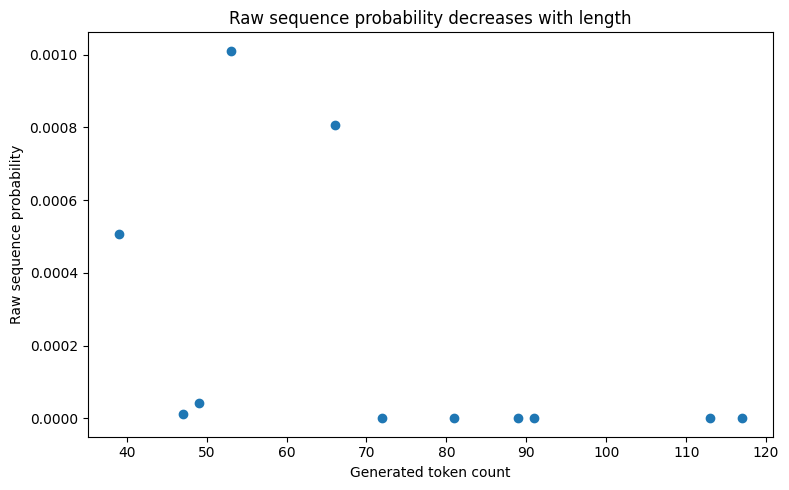

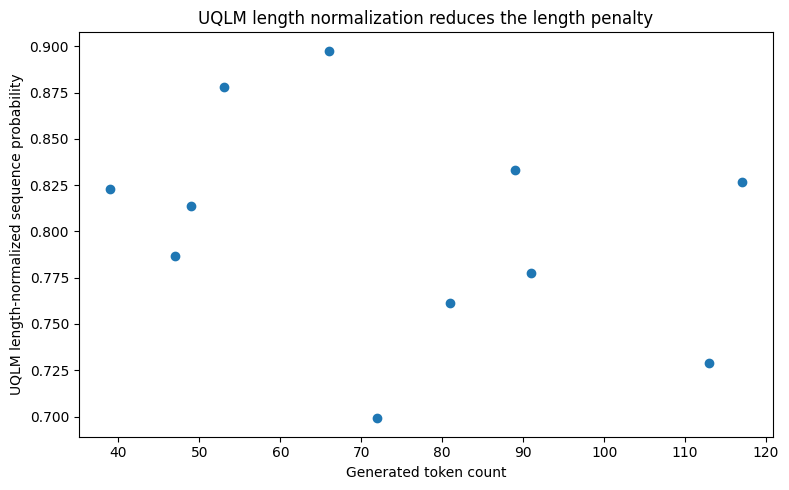

In [31]:
seq_scorer_raw = SingleLogprobsScorer(
    scorers=["sequence_probability"],
    length_normalize=False
)
raw_sequence = seq_scorer_raw.evaluate(
    logprobs_results=logprobs_list
)["sequence_probability"]

seq_scorer_uqlm_ln = SingleLogprobsScorer(
    scorers=["sequence_probability"],
    length_normalize=True
)
uqlm_ln_sequence = seq_scorer_uqlm_ln.evaluate(
    logprobs_results=logprobs_list
)["sequence_probability"]

length_norm_df = pd.DataFrame({
    "prompt_id": PROMPT_IDS,
    "generated_token_count": [
        token_count_from_logprobs(original_logprobs[pid]) for pid in PROMPT_IDS
    ],
    "raw_sequence_probability": raw_sequence,
    "uqlm_length_normalized_sequence_probability": uqlm_ln_sequence,
    "original_response": [original_responses[pid] for pid in PROMPT_IDS],
})

length_norm_df = length_norm_df.sort_values(
    "raw_sequence_probability",
    ascending=False
).reset_index(drop=True)

display(
    length_norm_df.style.format({
        "raw_sequence_probability": "{:.10f}",
        "uqlm_length_normalized_sequence_probability": "{:.6f}",
    })
)

print("Correlation with generated length:")
for col in [
    "raw_sequence_probability",
    "uqlm_length_normalized_sequence_probability",
]:
    corr_len = length_norm_df[["generated_token_count", col]].corr().iloc[0, 1]
    print(f"{col}: {corr_len:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    length_norm_df["generated_token_count"],
    length_norm_df["raw_sequence_probability"]
)
ax.set_xlabel("Generated token count")
ax.set_ylabel("Raw sequence probability")
ax.set_title("Raw sequence probability decreases with length")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    length_norm_df["generated_token_count"],
    length_norm_df["uqlm_length_normalized_sequence_probability"]
)
ax.set_xlabel("Generated token count")
ax.set_ylabel("UQLM length-normalized sequence probability")
ax.set_title("UQLM length normalization reduces the length penalty")
plt.tight_layout()
plt.show()


## Length-Normalized Variants of Monte Carlo Probability and CoCoA


This section is a sensitivity check. The main Monte Carlo Probability and CoCoA scores are kept in their native local scorer scale. Because both methods use sequence-probability information, their values can become very small for longer clinical responses.

Here, we compute custom variants that use UQLM length-normalized sequence probability inside Monte Carlo Probability and CoCoA. These variants reduce the effect of response length while keeping the same overall idea of each method.

These custom variants are not used to replace the main scorer outputs. They are included only to compare how the results change when the sequence-probability component is length-normalized.


In [32]:
seq_scorer_ln = SingleLogprobsScorer(
    scorers=["sequence_probability"],
    length_normalize=True,
)

sampled_ln_scores = []

for pid in PROMPT_IDS:
    sampled_ln = seq_scorer_ln.evaluate(
        logprobs_results=sampled_logprobs[pid]
    )["sequence_probability"]

    sampled_ln_scores.append(sampled_ln)


In [33]:
monte_carlo_probability_ln = [
    np.mean(scores) if len(scores) > 0 else np.nan
    for scores in sampled_ln_scores
]

monte_carlo_ln_df = summarize_scores(
    "monte_carlo_probability_ln",
    monte_carlo_probability_ln,
)


,prompt_id,score,original_response,ground_truth
0,p01,0.8130324929,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p11,0.7891390830,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
2,p07,0.7744617265,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
3,p04,0.7719422060,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
4,p02,0.7557618979,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
5,p03,0.6973020446,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
6,p06,0.6764331676,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
7,p08,0.6655632754,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
8,p09,0.6400626236,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
9,p05,0.5625796033,"The next therapeutic step is to escal

monte_carlo_probability_ln: higher = more confident
Highest-confidence prompt: p01 | score=0.813032
Lowest-confidence prompt:  p10 | score=0.550002
Mean score: 0.699662 | Std dev: 0.0901529
Displayed prompts: 11/11


In [35]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

cocoa_similarity_scores = []

for pid in tqdm(PROMPT_IDS, desc="Computing CoCoA similarity"):
    original_embedding = embedding_model.encode([original_responses[pid]])
    sample_embeddings = embedding_model.encode(sampled_responses[pid])

    similarities = cosine_similarity(
        original_embedding,
        sample_embeddings
    )[0]

    normalized_similarities = (similarities + 1) / 2
    cocoa_similarity_scores.append(np.mean(normalized_similarities))


Computing CoCoA similarity:   0%|          | 0/11 [00:00<?, ?it/s]

In [36]:
original_ln_sequence = seq_scorer_ln.evaluate(
    logprobs_results=logprobs_list
)["sequence_probability"]

cocoa_ln = [
    conf * sim
    for conf, sim in zip(original_ln_sequence, cocoa_similarity_scores)
]

cocoa_ln_df = summarize_scores(
    "cocoa_ln",
    cocoa_ln,
)


,prompt_id,score,original_response,ground_truth
0,p01,0.8695702365,"The diagnosis is ST-segment elevation myocardial infarction (STEMI), specifically an anterior wall MI. The immediate reperfusion management priority is to restore blood flow to the affected myocardium as quickly as p...","Anterior STEMI involving V1-V4 with elevated troponin; activate emergent reperfusion, preferably primary PCI within guideline time targets, with antiplatelet/anticoagulant support."
1,p11,0.8459861791,"The claim is **false**. Amoxicillin is an antibiotic that targets bacteria, not viruses. The appropriate management for an uncomplicated viral upper respiratory tract infection is supportive care, such as rest, fluid...",False: amoxicillin does not treat uncomplicated viral upper respiratory infections. Management is supportive care unless there is evidence of bacterial infection or another indication for antibiotics.
2,p07,0.8033287931,"Malignant hyperthermia (MH) is a pharmacogenetic disorder triggered by volatile anesthetics (e.g., halothane, sevoflurane) and succinylcholine, leading to uncontrolled skeletal muscle hypermetabolism, hyperthermia, a...",Usually autosomal-dominant RYR1 or CACNA1S susceptibility causing uncontrolled sarcoplasmic-reticulum calcium release; avoid volatile anesthetics and succinylcholine; dantrolene inhibits RyR1-mediated calcium release.
3,p03,0.7887533985,"Metformin lowers blood glucose in type 2 diabetes primarily by reducing hepatic glucose production. It achieves this through AMPK activation, which decreases gluconeogenesis, and by inhibiting mitochondrial complex I...","Metformin reduces hepatic glucose output mainly by inhibiting mitochondrial complex I, increasing cellular energy stress and AMPK-linked signaling, thereby suppressing gluconeogenesis."
4,p06,0.7748639362,"The patient's hyperkalemia and rising creatinine after starting an ACE inhibitor are likely due to the ACE inhibitor's inhibition of aldosterone production, leading to decreased potassium excretion and reduced glomer...","ACE inhibition reduces angiotensin-II efferent arteriolar tone and aldosterone-mediated potassium excretion; manage hyperkalemia urgently, review ACE inhibitor/renal function, stop contributors, and adjust therapy."
5,p02,0.7534133184,The clinical presentation and CSF findings are highly suggestive of *Neisseria meningitidis* meningitis. The first-line empirical antibiotic for this infection is intravenous ceftriaxone.,"Neisseria meningitidis meningitis; give immediate empiric IV ceftriaxone or cefotaxime, with supportive care and public-health prophylaxis for close contacts."
6,p04,0.7511732442,"The most likely diagnosis is lung cancer, specifically adenocarcinoma given the smoking history and clinical presentation. Mediastinoscopy is the best single investigation to establish nodal staging, as it provides d...",Likely non-small-cell lung cancer with mediastinal nodal disease; endobronchial ultrasound-guided transbronchial needle aspiration (EBUS-TBNA) is the key nodal staging test.
7,p08,0.7469589936,"Antiphospholipid syndrome (APS) is characterized by recurrent pregnancy loss, thrombosis, and positive lupus anticoagulant and anti-cardiolipin antibodies. Thrombosis in APS is caused by the formation of antibody-ant...","Antiphospholipid syndrome causes antibody-mediated endothelial/platelet/complement activation and thrombosis; warfarin is generally preferred over DOACs, especially in high-risk or arterial APS."
8,p09,0.7089935270,"Acquired resistance to osimertinib in NSCLC primarily stems from the C797S mutation, MET amplification, and small-cell transformation. The strongest current clinical evidence supports the use of amivantamab for C797S...","Osimertinib resistance may involve EGFR C797S, MET amplification, or small-cell transformation; strategies include molecularly guided EGFR combinations, MET-targeted therapy trials/combinations, or small-cell chemoth..."
9,p10,0.7028132348,"XR-7291 selectively disrupts cardioli

cocoa_ln: higher = more confident
Highest-confidence prompt: p01 | score=0.86957
Lowest-confidence prompt:  p05 | score=0.612109
Mean score: 0.759815 | Std dev: 0.0709641
Displayed prompts: 11/11


In [37]:
ln_variant_df = pd.DataFrame({
    "prompt_id": PROMPT_IDS,
    "monte_carlo_probability_original": TECHNIQUE_SCORES[
        "monte_carlo_probability"
    ].reindex(PROMPT_IDS).to_numpy(),
    "monte_carlo_probability_ln": monte_carlo_probability_ln,
    "cocoa_original": TECHNIQUE_SCORES[
        "cocoa"
    ].reindex(PROMPT_IDS).to_numpy(),
    "cocoa_ln": cocoa_ln,
})

display(
    ln_variant_df.style.format({
        "monte_carlo_probability_original": "{:.10f}",
        "monte_carlo_probability_ln": "{:.6f}",
        "cocoa_original": "{:.10f}",
        "cocoa_ln": "{:.6f}",
    })
)


,prompt_id,monte_carlo_probability_original,monte_carlo_probability_ln,cocoa_original,cocoa_ln
0,p01,0.0001749125,0.813032,0.0007811131,0.869570
1,p02,0.0002047311,0.755762,0.0004642494,0.753413
2,p03,0.0000253177,0.697302,0.0000398771,0.788753
3,p04,0.0001360916,0.771942,0.0000121826,0.751173
4,p05,0.0000000000,0.562580,0.0000000000,0.612109
5,p06,0.0000000148,0.676433,0.0000000824,0.774864
6,p07,0.0000000024,0.774462,0.0000000002,0.803329
7,p08,0.0000000000,0.665563,0.0000000001,0.746959
8,p09,0.0000000000,0.640063,0.0000000002,0.708994
9,p10,0.0000000000,0.550002,0.0000000000,0.702813


**Interpretation.** The length-normalized variants show how Monte Carlo Probability and CoCoA behave when their sequence-probability component is length-normalized. If the length-normalized scores are much larger than the original scores, that means the original values were strongly affected by response length. The main results still keep the native scorer outputs, while this section helps explain the scale difference.


## 19. All-prompt confidence ranking analysis

This section ranks every prompt under every uncertainty method. A rank of 1 means the prompt was scored as the highest-confidence output for that technique, while a larger rank means the prompt was closer to the low-confidence end of the prompt set.

This gives a broader view than focusing on only one prompt: it shows which prompts are repeatedly treated as uncertain across methods, including but not limited to the fabricated `p10` case and the false-premise `p11` control.


In [38]:
ranking_df = pd.DataFrame({"prompt_id": PROMPT_IDS})
for col in score_cols:
    ranking_df[col + "_rank"] = results_df[col].rank(
        ascending=False,
        method="min",
    ).astype("Int64")

display(ranking_df)

rank_long_df = ranking_df.melt(
    id_vars="prompt_id",
    var_name="technique",
    value_name="confidence_rank",
)
rank_long_df["technique"] = rank_long_df["technique"].str.replace(
    "_rank",
    "",
    regex=False,
)

low_confidence_threshold = len(PROMPT_IDS) - 2
low_confidence_summary_df = (
    rank_long_df.assign(
        ranked_low_confidence=rank_long_df["confidence_rank"] >= low_confidence_threshold
    )
    .groupby("prompt_id", as_index=False)
    .agg(
        mean_confidence_rank=("confidence_rank", "mean"),
        methods_ranking_low_confidence=("ranked_low_confidence", "sum"),
    )
    .sort_values(
        ["methods_ranking_low_confidence", "mean_confidence_rank"],
        ascending=[False, False],
    )
)

display(low_confidence_summary_df)


,prompt_id,min_probability_rank,sequence_probability_rank,mean_token_negentropy_rank,min_token_negentropy_rank,probability_margin_rank,p_true_rank,monte_carlo_probability_rank,cocoa_rank,semantic_negentropy_rank,semantic_density_rank
0,p01,1,2,1,1,1,6,3,2,1,2
1,p02,2,3,3,2,6,7,1,3,10,3
2,p03,4,4,6,7,5,5,5,4,9,11
3,p04,6,5,7,6,7,10,4,5,11,1
4,p05,7,10,11,10,11,3,10,10,4,10
5,p06,10,6,5,8,3,2,6,6,3,7
6,p07,8,8,4,4,4,1,7,8,5,9
7,p08,9,9,9,9,8,4,9,9,7,6
8,p09,5,7,8,5,9,8,8,7,2,5
9,p10,11,11,10,11,10,9,11,11,6,4


,prompt_id,mean_confidence_rank,methods_ranking_low_confidence
9,p10,9.4000000000,8
4,p05,8.6000000000,7
7,p08,7.9000000000,6
3,p04,6.2000000000,2
2,p03,6.0000000000,2
8,p09,6.4000000000,1
6,p07,5.8000000000,1
5,p06,5.6000000000,1
10,p11,4.1000000000,1
1,p02,4.0000000000,1


### All-prompt low-confidence ranking plot

The UQLM documentation often visualizes confidence-threshold behavior when benchmark correctness labels are available. This notebook uses a small qualitative medical prompt set, so this plot instead summarizes how often each prompt is placed near the low-confidence end across all techniques.

A higher bar means more uncertainty methods ranked that prompt among the lowest-confidence outputs.


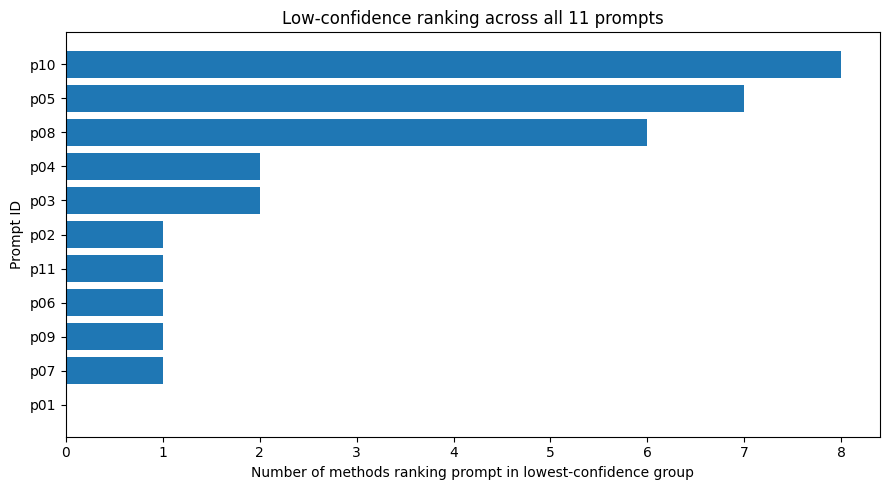

In [39]:
plot_df = low_confidence_summary_df.sort_values(
    "methods_ranking_low_confidence",
    ascending=True,
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    plot_df["prompt_id"],
    plot_df["methods_ranking_low_confidence"],
)
ax.set_xlabel("Number of methods ranking prompt in lowest-confidence group")
ax.set_ylabel("Prompt ID")
ax.set_title("Low-confidence ranking across all 11 prompts")
plt.tight_layout()
plt.show()


**Interpretation.** Prompts ranked low confidence by several methods deserve closer inspection because multiple uncertainty signals agree that the model was less certain. This analysis covers all 11 prompts, while still allowing known control cases such as `p10` and `p11` to be compared against the rest of the prompt set.


## 20. Technique comparison table

This compact table summarizes what each method measures, its main strength, weakness, and approximate computational cost.


In [40]:
technique_comparison_df = pd.DataFrame([
    ["Minimum Token Probability", "Lowest chosen-token probability", "Finds local fragile tokens", "Misses fluent global hallucinations", "1 generation"],
    ["Sequence Probability", "Joint response likelihood", "Global probability signal", "Strong length dependence", "1 generation"],
    ["Mean Token Negentropy", "Average top-k distribution sharpness", "Uses alternatives, not only chosen tokens", "Can reward fluent hallucination", "1 generation + top-k"],
    ["Minimum Token Negentropy", "Most diffuse top-k position", "Finds worst local ambiguity", "Sensitive to harmless wording choices", "1 generation + top-k"],
    ["Probability Margin", "Top-1 vs top-2 token gap", "Simple decision-margin signal", "Local margin ≠ factuality", "1 generation + top-k"],
    ["P(True)", "Self-rated answer correctness", "Directly targets correctness", "Self-evaluation bias", "+1 short generation"],
    ["Monte Carlo Probability", "Average probability across samples", "Smooths sequence-probability noise", "Still likelihood/length sensitive", "N sampled generations"],
    ["CoCoA", "Confidence × semantic consistency", "Catches inconsistent fabrications", "Embedding/sample-count sensitive", "N generations + embeddings"],
    ["Semantic Negentropy", "Concentration over semantic clusters", "Meaning-level uncertainty", "NLI-sensitive", "N generations + NLI"],
    ["Semantic Density", "Semantic neighborhood concentration", "Smooth semantic agreement signal", "Heavy and NLI-sensitive", "N generations + NLI"],
], columns=["Technique", "Measures", "Strength", "Weakness", "Cost"])
technique_comparison_df


,Technique,Measures,Strength,Weakness,Cost
0,Minimum Token Probability,Lowest chosen-token probability,Finds local fragile tokens,Misses fluent global hallucinations,1 generation
1,Sequence Probability,Joint response likelihood,Global probability signal,Strong length dependence,1 generation
2,Mean Token Negentropy,Average top-k distribution sharpness,"Uses alternatives, not only chosen tokens",Can reward fluent hallucination,1 generation + top-k
3,Minimum Token Negentropy,Most diffuse top-k position,Finds worst local ambiguity,Sensitive to harmless wording choices,1 generation + top-k
4,Probability Margin,Top-1 vs top-2 token gap,Simple decision-margin signal,Local margin ≠ factuality,1 generation + top-k
5,P(True),Self-rated answer correctness,Directly targets correctness,Self-evaluation bias,+1 short generation
6,Monte Carlo Probability,Average probability across samples,Smooths sequence-probability noise,Still likelihood/length sensitive,N sampled generations
7,CoCoA,Confidence × semantic consistency,Catches inconsistent fabrications,Embedding/sample-count sensitive,N generations + embeddings
8,Semantic Negentropy,Concentration over semantic clusters,Meaning-level uncertainty,NLI-sensitive,N generations + NLI
9,Semantic Density,Semantic neighborhood concentration,Smooth semantic agreement signal,Heavy and NLI-sensitive,N generations + NLI


## 21. Correlation heatmap using native scores

The heatmap below uses native scores directly. Correlations should be interpreted as agreement in prompt ranking, not equality of score scales.


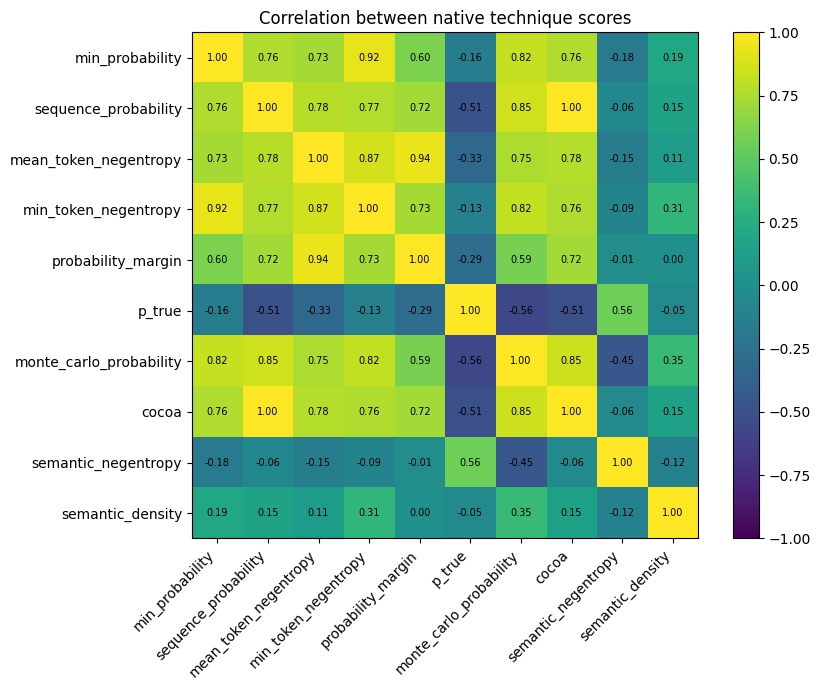

In [41]:
corr = results_df[score_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(score_cols)))
ax.set_xticklabels(score_cols, rotation=45, ha="right")
ax.set_yticks(range(len(score_cols)))
ax.set_yticklabels(score_cols)
ax.set_title("Correlation between native technique scores")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 22. Ranking comparison

Because score scales differ, rankings are often more interpretable than raw cross-method magnitudes. Rank 1 means highest confidence within that method.


,prompt_id,min_probability_rank,sequence_probability_rank,mean_token_negentropy_rank,min_token_negentropy_rank,probability_margin_rank,p_true_rank,monte_carlo_probability_rank,cocoa_rank,semantic_negentropy_rank,semantic_density_rank,mean_confidence_rank
0,p01,1,2,1,1,1,6,3,2,1,2,2.0000000000
1,p02,2,3,3,2,6,7,1,3,10,3,4.0000000000
2,p11,3,1,2,3,2,11,2,1,8,8,4.1000000000
3,p06,10,6,5,8,3,2,6,6,3,7,5.6000000000
4,p07,8,8,4,4,4,1,7,8,5,9,5.8000000000
5,p03,4,4,6,7,5,5,5,4,9,11,6.0000000000
6,p04,6,5,7,6,7,10,4,5,11,1,6.2000000000
7,p09,5,7,8,5,9,8,8,7,2,5,6.4000000000
8,p08,9,9,9,9,8,4,9,9,7,6,7.9000000000
9,p05,7,10,11,10,11,3,10,10,4,10,8.6000000000


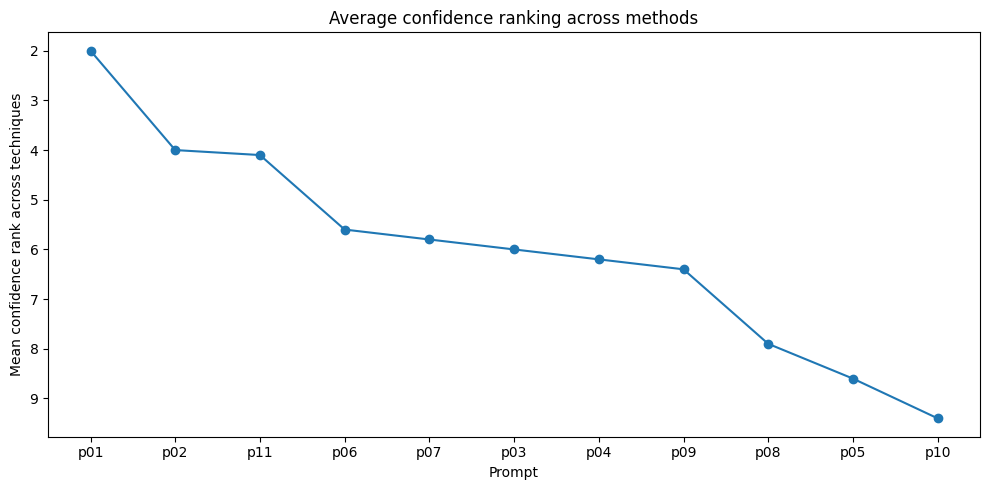

In [42]:
rank_cols = [c + "_rank" for c in score_cols]
ranking_comparison_df = ranking_df.copy()
ranking_comparison_df["mean_confidence_rank"] = ranking_comparison_df[rank_cols].mean(axis=1)
ranking_comparison_df = ranking_comparison_df.sort_values("mean_confidence_rank").reset_index(drop=True)
display(ranking_comparison_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranking_comparison_df["prompt_id"], ranking_comparison_df["mean_confidence_rank"], marker="o")
ax.set_xlabel("Prompt")
ax.set_ylabel("Mean confidence rank across techniques")
ax.set_title("Average confidence ranking across methods")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 23. Conclusion

Token-level methods are the cheapest and most transparent. Minimum token probability, negentropy, and probability margin expose local uncertainty in the generated text, but they can miss hallucinations that are locally fluent.

Sequence-style probability methods provide global likelihood signals, and Monte Carlo probability makes that signal less dependent on one greedy answer. Their main limitation is that likelihood is not the same as truth, and raw sequence probability is length-sensitive.

P(True) is attractive because it asks directly about correctness, but it inherits the model's self-evaluation bias. The `p10` fabricated-compound prompt and the `p11` false-premise control help interpret this behavior, but the final comparison is based on all 11 prompts.

Sampling-based semantic methods, especially CoCoA, Semantic Negentropy, and Semantic Density, are more expensive but can be better aligned with hallucination detection when unsupported prompts produce inconsistent sampled explanations. In a research setting, the strongest workflow is to compare cheap token-level signals with semantic sampling signals and inspect disagreements across the full prompt set.

The documentation-style preview tables near the beginning of the white-box and multi-generation sections show the same objects UQLM uses internally: prompts, responses, token logprobs, sampled responses, and confidence scores. These previews make the scoring pipeline transparent before interpreting final comparisons.
